# Phase 3: Regime Validation

**Goal:** Confirm that the 4 HMM-discovered regimes are economically meaningful by computing per-regime statistics and matching them to known historical events.

**Inputs:** `data/raw/master.csv` (with `regime_label` column from Phase 2)  
**Outputs:** Characterization table + 3 visualizations

## 0. Imports & Config

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import itertools
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style='darkgrid')

DATA_RAW = Path('../data/raw')
FIGURES  = Path('../results/figures')

REGIME_COLORS = {0: '#90EE90', 1: '#FF6B6B', 2: '#FFD700', 3: '#87CEEB'}

print('Setup complete.')

Setup complete.


## 1. Load Data & Compute Per-Regime Statistics

In [2]:
df = pd.read_csv(DATA_RAW / 'master.csv', index_col=0, parse_dates=True)
print(f'Loaded: {df.shape[0]:,} rows | regimes: {sorted(df["regime_label"].unique())}')

n_regimes = df['regime_label'].nunique()

# Compute growth vs value daily return spread (XLK - XLP log returns)
df['xlk_return'] = np.log(df['xlk'] / df['xlk'].shift(1))
df['xlp_return'] = np.log(df['xlp'] / df['xlp'].shift(1))
df['growth_vs_value'] = df['xlk_return'] - df['xlp_return']

df.head(3)

Loaded: 6,017 rows | regimes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


,xle,xlf,xlk,xlp,xlv,xly,gspc,vix,treasury_10y,treasury_2y,fed_funds_rate,sp500_return,realized_vol_20d,yield_spread,growth_value_spread,regime_label,xlk_return,xlp_return,growth_vs_value
Date,,,,,,,,,,,,,,,,,,,
2000-02-01,6.828186,11.242419,19.207884,12.272217,20.577791,10.433845,1409.280029,23.450001,6.62,6.60,5.73,0.010572,0.263633,0.02,0.447983,2,NaN,NaN,NaN
2000-02-02,6.871253,11.128785,19.347406,12.297229,21.083805,10.364439,1409.119995,23.120001,6.60,6.63,5.73,-0.000114,0.223332,-0.03,0.453184,2,0.007238,0.002036,0.005202
2000-02-03,6.789033,11.060602,19.905508,12.130485,21.273560,10.404932,1424.969971,22.010000,6.49,6.56,5.73,0.011185,0.226596,-0.07,0.495275,2,0.028438,-0.013652,0.042090


In [3]:
# Per-regime statistics
stats = df.groupby('regime_label').agg(
    days           = ('sp500_return', 'count'),
    mean_return    = ('sp500_return', 'mean'),
    std_return     = ('sp500_return', 'std'),
    mean_vix       = ('vix', 'mean'),
    mean_yield_spread = ('yield_spread', 'mean'),
    mean_growth_vs_value = ('growth_vs_value', 'mean'),
    mean_vol       = ('realized_vol_20d', 'mean'),
).round(4)

total_days = len(df)
stats['pct_history'] = (stats['days'] / total_days * 100).round(1)
stats['ann_return_pct'] = (stats['mean_return'] * 252 * 100).round(2)

print('Per-regime statistics:')
print(stats.to_string())

Per-regime statistics:
              days  mean_return  std_return  mean_vix  mean_yield_spread  mean_growth_vs_value  mean_vol  pct_history  ann_return_pct
regime_label                                                                                                                         
0             1654       0.0007      0.0074   16.1363             2.0100                0.0003    0.1164         27.5           17.64
1              638      -0.0011      0.0257   37.2901             1.9776                0.0003    0.3667         10.6          -27.72
2             2176      -0.0001      0.0128   22.9883             0.7925               -0.0007    0.1951         36.2           -2.52
3             1549       0.0007      0.0059   12.9630             0.3578                0.0005    0.0936         25.7           17.64


In [4]:
# Compute regime episode durations via run-length encoding
def get_episode_durations(labels):
    durations = {r: [] for r in range(n_regimes)}
    for regime, group in itertools.groupby(labels):
        durations[regime].append(sum(1 for _ in group))
    return durations

durations = get_episode_durations(df['regime_label'].values)

print('Episode duration summary per regime:')
for r, d in sorted(durations.items()):
    print(f'  Regime {r}: {len(d)} episodes | mean={np.mean(d):.1f}d | '
          f'median={np.median(d):.1f}d | max={np.max(d)}d')

Episode duration summary per regime:
  Regime 0: 16 episodes | mean=103.4d | median=40.0d | max=564d
  Regime 1: 8 episodes | mean=79.8d | median=42.5d | max=207d
  Regime 2: 36 episodes | mean=60.4d | median=27.5d | max=405d
  Regime 3: 13 episodes | mean=119.2d | median=77.0d | max=391d


## 2. Regime Characterization Table

In [5]:
# Map regime labels to economic names based on their statistics
# Assign names: sort by mean VIX to identify crisis vs calm
vix_rank = stats['mean_vix'].rank()
vol_rank = stats['mean_vol'].rank()

# Print full characterization table
char_table = pd.DataFrame({
    'Days': stats['days'],
    '% History': stats['pct_history'],
    'Ann. Return %': stats['ann_return_pct'],
    'Mean VIX': stats['mean_vix'].round(1),
    'Mean Vol (ann.)': stats['mean_vol'].round(3),
    'Yield Spread': stats['mean_yield_spread'].round(3),
    'Growth vs Value': stats['mean_growth_vs_value'].round(4),
    'Mean Episode (d)': [f"{np.mean(durations[r]):.1f}" for r in sorted(durations)],
})

print('=== PHASE 3 REGIME CHARACTERIZATION TABLE ===')
print(char_table.to_string())

print()
print('--- Economic Interpretation ---')
for r in sorted(stats.index):
    row = stats.loc[r]
    sign = '+' if row['ann_return_pct'] > 0 else ''
    print(f'Regime {r}: VIX={row["mean_vix"]:.1f}, Vol={row["mean_vol"]:.3f}, '
          f'YieldSprd={row["mean_yield_spread"]:.3f}, AnnRet={sign}{row["ann_return_pct"]:.2f}%')

=== PHASE 3 REGIME CHARACTERIZATION TABLE ===
              Days  % History  Ann. Return %  Mean VIX  Mean Vol (ann.)  Yield Spread  Growth vs Value Mean Episode (d)
regime_label                                                                                                           
0             1654       27.5          17.64      16.1            0.116         2.010           0.0003            103.4
1              638       10.6         -27.72      37.3            0.367         1.978           0.0003             79.8
2             2176       36.2          -2.52      23.0            0.195         0.792          -0.0007             60.4
3             1549       25.7          17.64      13.0            0.094         0.358           0.0005            119.2

--- Economic Interpretation ---
Regime 0: VIX=16.1, Vol=0.116, YieldSprd=2.010, AnnRet=+17.64%
Regime 1: VIX=37.3, Vol=0.367, YieldSprd=1.978, AnnRet=-27.72%
Regime 2: VIX=23.0, Vol=0.195, YieldSprd=0.792, AnnRet=-2.52%
Regime 3: VIX

## 3. Visualizations

### VIZ 3.1 — Regime Statistics Bar Charts

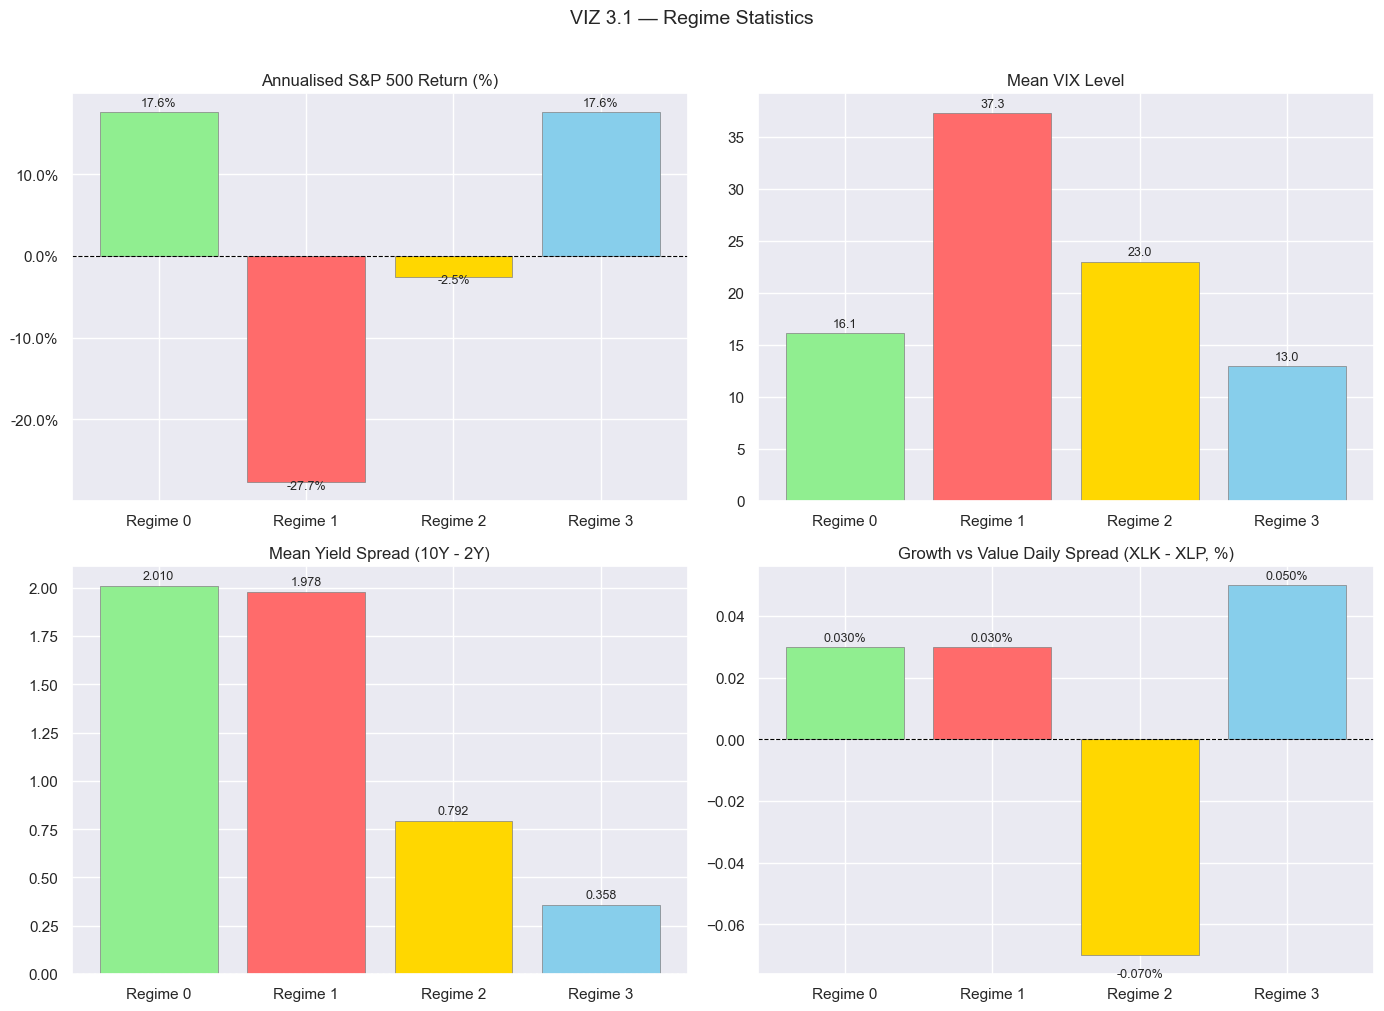

In [6]:
regimes = sorted(stats.index)
colors  = [REGIME_COLORS[r] for r in regimes]
x       = np.arange(len(regimes))
labels  = [f'Regime {r}' for r in regimes]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VIZ 3.1 — Regime Statistics', fontsize=14, y=1.01)

# Panel 1: Annualised return
ax = axes[0, 0]
bars = ax.bar(x, stats.loc[regimes, 'ann_return_pct'], color=colors, edgecolor='gray', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Annualised S&P 500 Return (%)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
for bar, val in zip(bars, stats.loc[regimes, 'ann_return_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.3 if val >= 0 else -1.2),
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Panel 2: Mean VIX
ax = axes[0, 1]
bars = ax.bar(x, stats.loc[regimes, 'mean_vix'], color=colors, edgecolor='gray', linewidth=0.5)
ax.set_title('Mean VIX Level')
ax.set_xticks(x); ax.set_xticklabels(labels)
for bar, val in zip(bars, stats.loc[regimes, 'mean_vix']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# Panel 3: Mean yield spread
ax = axes[1, 0]
bars = ax.bar(x, stats.loc[regimes, 'mean_yield_spread'], color=colors, edgecolor='gray', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Mean Yield Spread (10Y - 2Y)')
ax.set_xticks(x); ax.set_xticklabels(labels)
for bar, val in zip(bars, stats.loc[regimes, 'mean_yield_spread']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.02 if val >= 0 else -0.08),
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Panel 4: Growth vs value spread
ax = axes[1, 1]
bars = ax.bar(x, stats.loc[regimes, 'mean_growth_vs_value'] * 100, color=colors, edgecolor='gray', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Growth vs Value Daily Spread (XLK - XLP, %)')
ax.set_xticks(x); ax.set_xticklabels(labels)
for bar, val in zip(bars, stats.loc[regimes, 'mean_growth_vs_value'] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.001 if val >= 0 else -0.008),
            f'{val:.3f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
FIGURES.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES / 'viz_3_1_regime_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

### VIZ 3.2 — Regime Duration Histograms

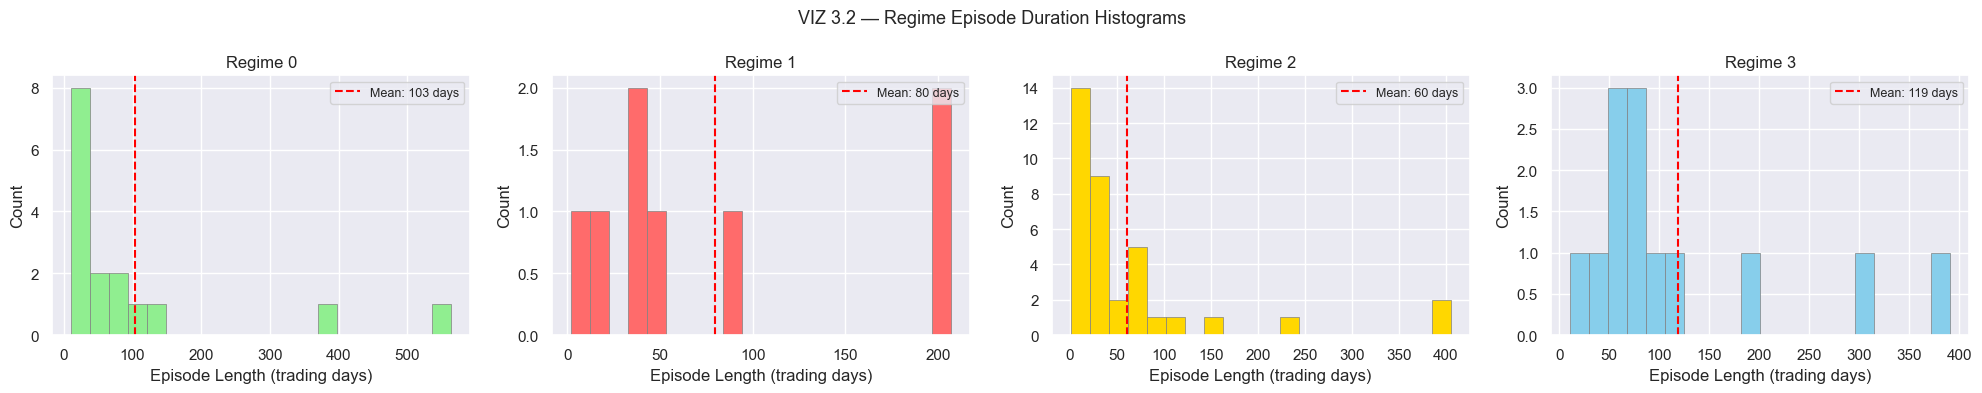

In [7]:
fig, axes = plt.subplots(1, n_regimes, figsize=(5 * n_regimes, 4))
fig.suptitle('VIZ 3.2 — Regime Episode Duration Histograms', fontsize=13)

for ax, r in zip(axes, regimes):
    d = durations[r]
    ax.hist(d, bins=20, color=REGIME_COLORS[r], edgecolor='gray', linewidth=0.5)
    mean_d = np.mean(d)
    ax.axvline(mean_d, color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {mean_d:.0f} days')
    ax.set_title(f'Regime {r}')
    ax.set_xlabel('Episode Length (trading days)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'viz_3_2_regime_duration_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

### VIZ 3.3 — Regime Time Allocation Pie Chart

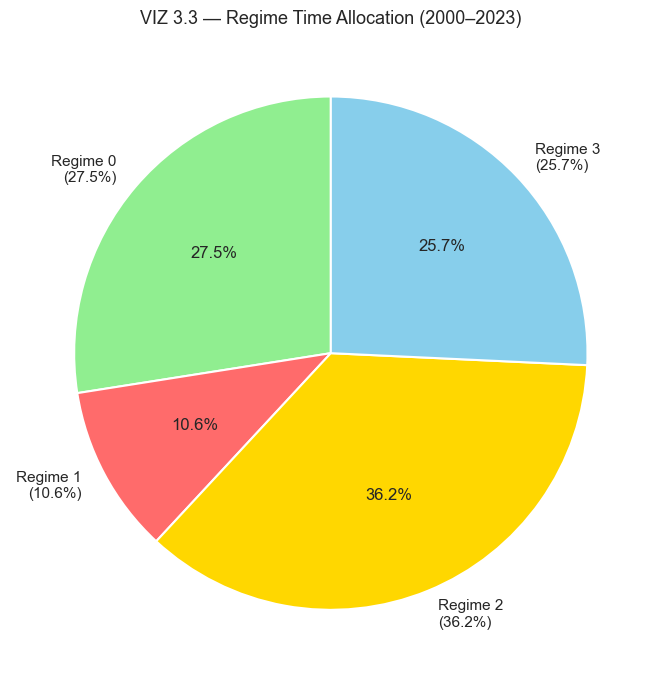

In [8]:
counts = df['regime_label'].value_counts().sort_index()
pie_colors = [REGIME_COLORS[r] for r in counts.index]
pie_labels = [f'Regime {r}\n({counts[r]/total_days*100:.1f}%)' for r in counts.index]

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(counts.values, labels=pie_labels, colors=pie_colors,
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('VIZ 3.3 — Regime Time Allocation (2000–2023)', fontsize=13)

plt.tight_layout()
plt.savefig(FIGURES / 'viz_3_3_regime_time_allocation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Phase 3 Gate Checks

In [9]:
# Gate: all regime mean episode durations > 10 trading days
for r in regimes:
    mean_dur = np.mean(durations[r])
    assert mean_dur > 10, f'FAIL: Regime {r} mean duration {mean_dur:.1f}d < 10d (HMM too noisy)'

# Gate: crisis regime (highest VIX) has negative annualised return
crisis_regime = stats['mean_vix'].idxmax()
assert stats.loc[crisis_regime, 'ann_return_pct'] < 0, \
    f'FAIL: crisis regime {crisis_regime} has positive return — check regime alignment'

# Gate: calm regime (lowest VIX) has positive annualised return
calm_regime = stats['mean_vix'].idxmin()
assert stats.loc[calm_regime, 'ann_return_pct'] > 0, \
    f'FAIL: calm regime {calm_regime} has negative return — check regime alignment'

# Gate: crisis regime is not >30% of history
crisis_pct = stats.loc[crisis_regime, 'pct_history']
assert crisis_pct <= 30, \
    f'FAIL: crisis regime is {crisis_pct:.1f}% of history (>30% means K may be too low)'

# Gate: visualisations saved
for fname in ['viz_3_1_regime_statistics.png', 'viz_3_2_regime_duration_histogram.png',
              'viz_3_3_regime_time_allocation.png']:
    assert (FIGURES / fname).exists(), f'FAIL: {fname} not found'

print('All Phase 3 gate checks PASSED.')
print(f'Crisis regime: {crisis_regime} (VIX={stats.loc[crisis_regime,"mean_vix"]:.1f}, '
      f'AnnRet={stats.loc[crisis_regime,"ann_return_pct"]:.2f}%, {crisis_pct:.1f}% of history)')
print(f'Calm  regime: {calm_regime}  (VIX={stats.loc[calm_regime,"mean_vix"]:.1f}, '
      f'AnnRet={stats.loc[calm_regime,"ann_return_pct"]:.2f}%, {stats.loc[calm_regime,"pct_history"]:.1f}% of history)')

All Phase 3 gate checks PASSED.
Crisis regime: 1 (VIX=37.3, AnnRet=-27.72%, 10.6% of history)
Calm  regime: 3  (VIX=13.0, AnnRet=17.64%, 25.7% of history)
